# e13f transferability + permutation-equivariance — analysis

**Checkpoint:** `outputs/e13f_alpha_khops/e13f_alpha00_ai8c2bm0` (e13f_alpha00, ~0.79 on the N=30 nav-GT eval)
**Eval set:** `data/n_100/gen/nav_n100_gemma_data/test_graphs` (10 graphs, N=100 nodes)
**Arms:** no-perm (`results/e13f_transferability/`) · permutation seeds 32/77/99 (`results/e13f_transferability_perm/`)
Pulled from betty 2026-07-24. SPINE arm not run.

---
> ⚠️ **Read before drawing conclusions — three integrity issues found in the raw data (Section 0):**
> 1. **The permutation was never applied.** All three seeds serialise `permutation=None`, meaning
>    `Permutation.apply()` never fired. The 3 "perm" seeds are identical *unpermuted* reruns differing
>    only by generation sampling — so this run does **not** measure permutation equivariance.
> 2. **`data_gen_005` crashes** 10/10 in every arm: `RuntimeError: cannot reshape tensor of 0 elements
>    into shape [320, 0, -1]` (a degenerate/empty graph tensor), not a wrong answer.
> 3. **Accuracy is ~2–3% everywhere**, vs ~0.79 in training eval. Real N=30→N=100 collapse or a harness/
>    data artifact — undetermined. Interpretation is yours; this notebook only lays out the evidence.


## 0. Setup

In [1]:
import json, glob, os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Notebook runs from notebooks/; fall back to repo root if results/ isn't beside us.
REPO = Path.cwd()
REPO = REPO if (REPO / "results").exists() else REPO.parent
NOPERM_DIR = REPO / "results/e13f_transferability"
PERM_DIR   = REPO / "results/e13f_transferability_perm"
CKPT       = "e13f_alpha00_ai8c2bm0"
PERM_SEEDS = [32, 77, 99]
print("REPO:", REPO)

REPO: /home/jporras/sourcecode/GREP-PRISM


In [2]:
def load_noperm():
    """cross_eval layout: results/e13f_transferability/<graph>.json (one dict per graph)."""
    rows, samples = [], {}
    for f in sorted(NOPERM_DIR.glob("data_gen_*.json")):
        d = json.load(open(f))
        s = d["samples"]
        n_err = sum(1 for x in s if x.get("error") or x.get("terminated_by") == "exception")
        rows.append(dict(graph=f.stem, accuracy=d["accuracy"],
                         num_correct=d["num_correct"], num_samples=d["num_samples"],
                         num_error=n_err))
        samples[f.stem] = s
    return pd.DataFrame(rows), samples

def load_perm_summary(seed):
    """transferability layout: perm_<seed>/<ckpt>_summary.json (trials[])."""
    p = PERM_DIR / f"perm_{seed}" / f"{CKPT}_summary.json"
    s = json.load(open(p))
    rows = [dict(graph=t["name"].replace(".json", ""), accuracy=t["accuracy"],
                 num_correct=t["num_correct"], num_total=t["num_total"],
                 num_error=t["num_errors"], num_keyword=t["num_keyword"],
                 elapsed_s=t["elapsed_s"]) for t in s["trials"]]
    return s["permutation"], pd.DataFrame(rows)

noperm_df, samples = load_noperm()

## 0. Integrity checks (deterministic — run first)

These are the guardrails. If either fails, the accuracy tables below describe a broken run, not a result.

In [3]:
def check_permutation_applied():
    """Permutation.to_dict() serialises perm=None iff .apply() never fired
    (lazy materialisation in models/utils.py). A materialised array is the only
    proof the equivariance test actually permuted node indices."""
    print("Permutation-applied check (perm array must be non-null):\n")
    all_ok = True
    for seed in PERM_SEEDS:
        perm, _ = load_perm_summary(seed)
        applied = perm.get("permutation") is not None
        all_ok &= applied
        print(f"  perm_{seed}: num_nodes={str(perm['num_nodes']):>5}  "
              f"{'<materialised>' if applied else 'permutation=None'}  ->  "
              f"{'APPLIED' if applied else 'NOT APPLIED (no-op!)'}")
    verdict = "PASS" if all_ok else ("FAIL - permutation never applied; "
                                     "the 3 seeds are identical unpermuted reruns")
    print(f"\n  RESULT: {verdict}")
    return all_ok

check_permutation_applied();

Permutation-applied check (perm array must be non-null):

  perm_32: num_nodes= None  permutation=None  ->  NOT APPLIED (no-op!)
  perm_77: num_nodes= None  permutation=None  ->  NOT APPLIED (no-op!)
  perm_99: num_nodes= None  permutation=None  ->  NOT APPLIED (no-op!)

  RESULT: FAIL - permutation never applied; the 3 seeds are identical unpermuted reruns


In [4]:
def check_crashes(samples):
    """Surface graphs whose samples died with an exception, not a wrong answer."""
    rows = []
    for g, s in samples.items():
        errs = [x for x in s if x.get("error") or x.get("terminated_by") == "exception"]
        if errs:
            rows.append(dict(graph=g, n_crashed=len(errs), n_total=len(s),
                             example=(errs[0].get("error") or "")[:70]))
    df = pd.DataFrame(rows)
    print("Crash check (samples terminated by exception):\n")
    print("  none" if df.empty else df.to_string(index=False))
    return df

crash_df = check_crashes(samples)

Crash check (samples terminated by exception):

       graph  n_crashed  n_total                                                                example
data_gen_005         10       10 RuntimeError: cannot reshape tensor of 0 elements into shape [320, 0, 


## 1. No-perm transferability accuracy

In [5]:
display(noperm_df)

tot_all = dict(scope="all 10 graphs",
               accuracy=noperm_df.num_correct.sum() / noperm_df.num_samples.sum(),
               num_correct=noperm_df.num_correct.sum(), num_samples=noperm_df.num_samples.sum())
clean = noperm_df[noperm_df.num_error == 0]
tot_clean = dict(scope="excl. crashed graphs",
                 accuracy=clean.num_correct.sum() / clean.num_samples.sum(),
                 num_correct=clean.num_correct.sum(), num_samples=clean.num_samples.sum())
pd.DataFrame([tot_all, tot_clean])

,graph,accuracy,num_correct,num_samples,num_error
0,data_gen_001,0.0,0,10,0
1,data_gen_004,0.0,0,10,0
2,data_gen_005,0.0,0,10,10
3,data_gen_010,0.0,0,10,0
4,data_gen_012,0.0,0,10,0
5,data_gen_013,0.0,0,10,0
6,data_gen_017,0.1,1,10,0
7,data_gen_020,0.0,0,10,0
8,data_gen_021,0.0,0,10,0
9,data_gen_022,0.2,2,10,0


,scope,accuracy,num_correct,num_samples
0,all 10 graphs,0.030000,3,100
1,excl. crashed graphs,0.033333,3,90


## 2. Permutation arm vs no-perm (per-graph accuracy)

If the permutation had been applied *and* the model were not permutation-invariant, the `perm_*` columns
would diverge from `no_perm`. Given Section 0 flagged the permutation as a no-op, expect near-identity here
(any small differences are generation-sampling noise, not permutation effects).

In [6]:
wide = noperm_df[["graph", "accuracy"]].rename(columns={"accuracy": "no_perm"}).set_index("graph")
for seed in PERM_SEEDS:
    _, pdf = load_perm_summary(seed)
    wide[f"perm_{seed}"] = pdf.set_index("graph")["accuracy"]
display(wide)
print("column means:")
print(wide.mean().round(3).to_string())

,no_perm,perm_32,perm_77,perm_99
graph,,,,
data_gen_001,0.0,0.0,0.0,0.0
data_gen_004,0.0,0.0,0.0,0.0
data_gen_005,0.0,0.0,0.0,0.0
data_gen_010,0.0,0.0,0.0,0.0
data_gen_012,0.0,0.0,0.0,0.0
data_gen_013,0.0,0.0,0.0,0.0
data_gen_017,0.1,0.0,0.0,0.1
data_gen_020,0.0,0.0,0.0,0.0
data_gen_021,0.0,0.0,0.0,0.0


column means:
no_perm    0.03
perm_32    0.01
perm_77    0.02
perm_99    0.03


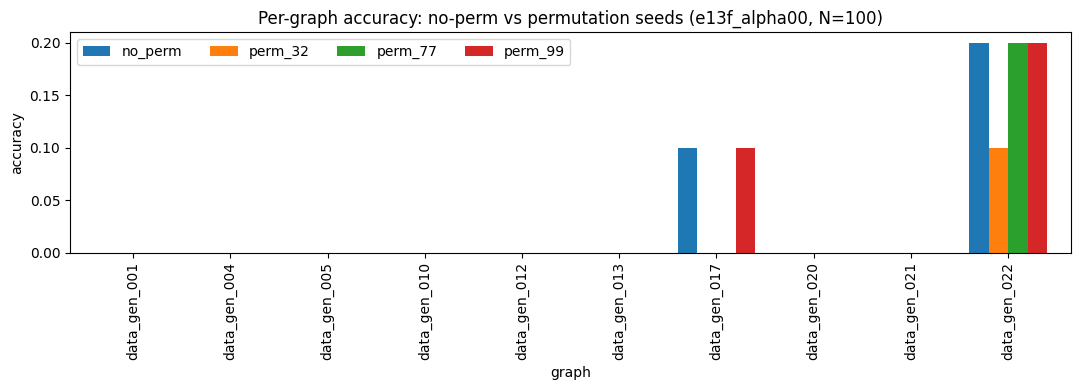

In [7]:
ax = wide.plot(kind="bar", figsize=(11, 4), width=0.8)
ax.set_ylabel("accuracy"); ax.set_title("Per-graph accuracy: no-perm vs permutation seeds (e13f_alpha00, N=100)")
ax.legend(title=None, ncol=4); plt.tight_layout(); plt.show()

## 3. Notes & open questions

Deliberately not interpreting the science — these are engineering observations + what to check.

**Permutation no-op (Section 0.1) — highest priority.** The wiring is present but not firing:
- `models/gt.py:325` and `models/r_pearl.py:204` call `permutation.apply(edge_index, ...)` *iff* a non-None
  `permutation` reaches that forward.
- `Permutation.to_dict()` proves `.apply()` never ran → `permutation` arrives as `None` at the PE forward.
- Separately, `eval/evaluate.py:263` gates the *text-shuffle* permutation behind `not is_gnn`, so for a
  graph-augmented checkpoint that path is skipped too.
- **Open question for you:** where does `permutation` get dropped between `eval_model_multiple_graphs`
  (evaluate.py:258) and the GT/R-PEARL forward? That threading is inside your PE integration — I stopped
  here rather than edit the novel path.

**`data_gen_005` crash (Section 0.2).** `reshape ... [320, 0, -1]` → a 0-sized dim, consistent with an empty
edge set / zero-node subgraph for that graph specifically. Reproduces in every arm including no-perm, so it's
graph-data or graph-loading, independent of the permutation issue. Worth checking whether 005 is malformed on
disk, and — since one graph provably feeds a degenerate tensor — whether the *non-crashing* graphs also get
degenerate PE inputs (which could be part of why accuracy is ~2%).

**What I'm unsure about / for you to decide:**
- Is ~2–3% a genuine N=30→N=100 transfer collapse, or downstream of the input-degeneracy hinted at by 005?
  Same-seed `no_perm` vs `perm_*` being near-identical is consistent with "no permutation applied," not with
  either interpretation of the accuracy itself.
- Whether to re-run the permutation arm after the threading is fixed before this analysis means anything for
  equivariance. The `check_permutation_applied()` cell will flip to PASS once `.apply()` actually fires.
